# Evaluación del Riesgo Crediticio usando Lógica Difusa

Aplicación de lógica difusa en procesos bancarios para determinar el nivel de riesgo crediticio.

Método: Mamdani
Defuzzificación: Centroide
Librería: scikit-fuzzy

In [2]:
!pip install scikit-fuzzy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

## Definición de Universos de Discurso

- Ingresos: 0 – 10,000 USD
- Historial crediticio: 0 – 100
- Endeudamiento: 0 – 100 %
- Riesgo crediticio: 0 – 100

In [4]:
ingresos = ctrl.Antecedent(np.arange(0, 10001, 1), 'ingresos')
historial = ctrl.Antecedent(np.arange(0, 101, 1), 'historial')
endeudamiento = ctrl.Antecedent(np.arange(0, 101, 1), 'endeudamiento')
riesgo = ctrl.Consequent(np.arange(0, 101, 1), 'riesgo')

## Funciones de Pertenencia

In [5]:
ingresos['bajo'] = fuzz.trapmf(ingresos.universe, [0, 0, 2000, 4000])
ingresos['medio'] = fuzz.trimf(ingresos.universe, [3000, 5000, 7000])
ingresos['alto'] = fuzz.trapmf(ingresos.universe, [6000, 8000, 10000, 10000])

historial['malo'] = fuzz.trapmf(historial.universe, [0, 0, 30, 50])
historial['regular'] = fuzz.trimf(historial.universe, [40, 60, 75])
historial['bueno'] = fuzz.trapmf(historial.universe, [70, 85, 100, 100])

endeudamiento['bajo'] = fuzz.trapmf(endeudamiento.universe, [0, 0, 20, 40])
endeudamiento['medio'] = fuzz.trimf(endeudamiento.universe, [30, 50, 70])
endeudamiento['alto'] = fuzz.trapmf(endeudamiento.universe, [60, 80, 100, 100])

riesgo['bajo'] = fuzz.trapmf(riesgo.universe, [0, 0, 30, 50])
riesgo['medio'] = fuzz.trimf(riesgo.universe, [40, 60, 75])
riesgo['alto'] = fuzz.trapmf(riesgo.universe, [70, 85, 100, 100])

C:\Users\cyanezru\AppData\Roaming\Python\Python314\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


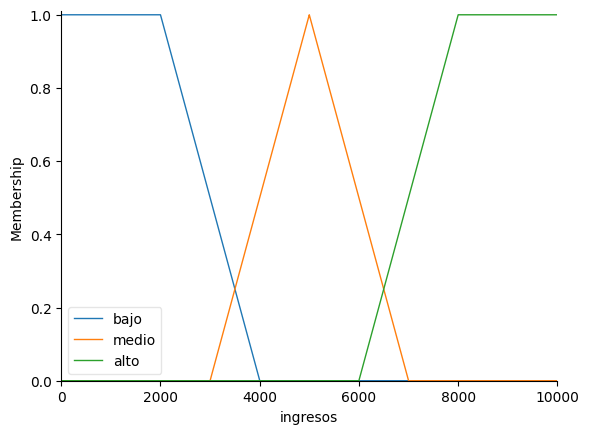

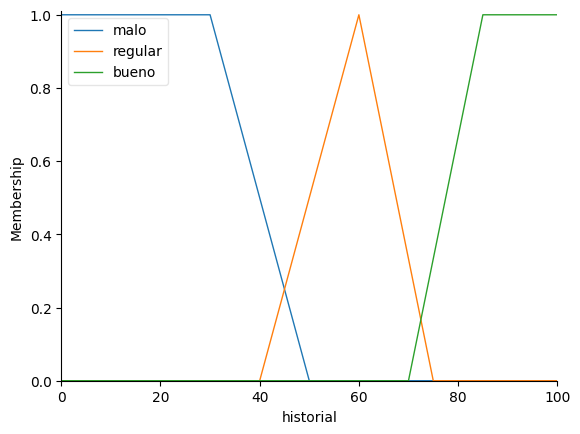

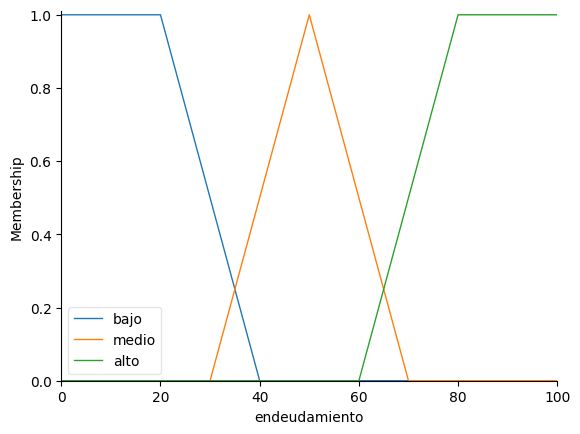

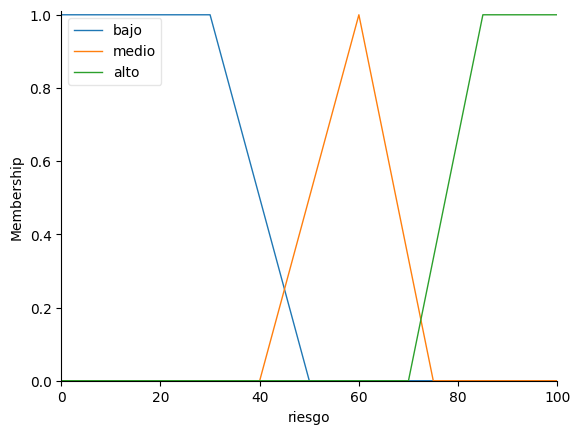

In [6]:
ingresos.view()
historial.view()
endeudamiento.view()
riesgo.view()

## Reglas Difusas

In [7]:
regla1 = ctrl.Rule(ingresos['alto'] & historial['bueno'] & endeudamiento['bajo'], riesgo['bajo'])
regla2 = ctrl.Rule(ingresos['bajo'] & historial['malo'], riesgo['alto'])
regla3 = ctrl.Rule(endeudamiento['alto'], riesgo['alto'])
regla4 = ctrl.Rule(historial['regular'] & ingresos['medio'], riesgo['medio'])
regla5 = ctrl.Rule(ingresos['medio'] & endeudamiento['medio'], riesgo['medio'])
regla6 = ctrl.Rule(historial['bueno'] & endeudamiento['bajo'], riesgo['bajo'])

In [8]:
sistema = ctrl.ControlSystem([regla1, regla2, regla3, regla4, regla5, regla6])
simulador = ctrl.ControlSystemSimulation(sistema)

## Simulación

In [9]:
simulador.input['ingresos'] = 4500
simulador.input['historial'] = 65
simulador.input['endeudamiento'] = 55

simulador.compute()

print("Nivel de Riesgo Crediticio:", simulador.output['riesgo'])

Nivel de Riesgo Crediticio: 58.24999999999998


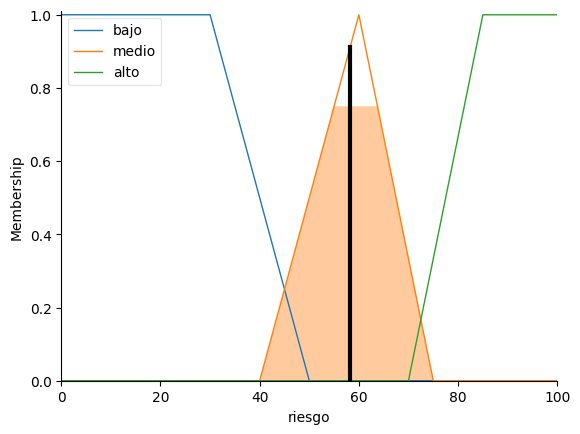

In [10]:
riesgo.view(sim=simulador)